<a href="https://colab.research.google.com/github/saradindu-chaudhuri/SC/blob/master/CHeBA_Interpretable_ML_Alzheimers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CHeBA Preparation: Interpretable Machine Learning for Dementia Diagnosis
**Author:** Saradindu Chaudhuri, Master of Data Science (UNSW)
**Objective:** Evaluate feature importance and model interpretability (SHAP) on clinical Alzheimer's diagnostic data.

In [5]:
import pandas as pd

# Load the dataset
df = pd.read_csv('alzheimers_disease_data.csv')

# Display basic information and first 5 rows
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [6]:
!pip install shap


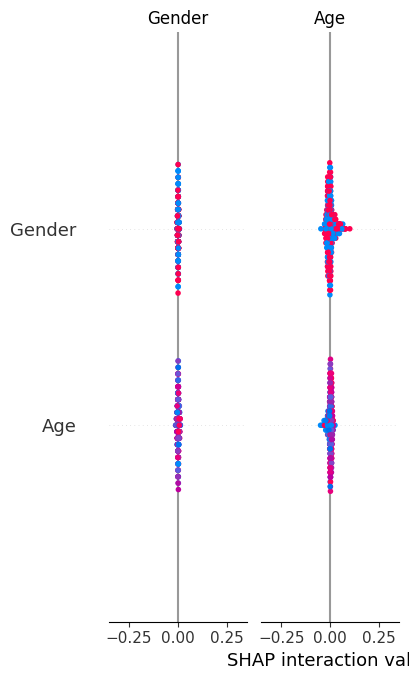

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import shap

# 1. Clean up columns - drop IDs or non-predictive text columns
X = df.drop(columns=['PatientID', 'DoctorInCharge', 'Diagnosis'])
y = df['Diagnosis']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit a Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Generate SHAP values for Model Interpretability
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 5. Plot SHAP Summary
# (If shap_values is a list for binary classification, use index 1 for positive class)
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test)
else:
    shap.summary_plot(shap_values, X_test)

100%|===================| 856/860 [00:26<00:00]       

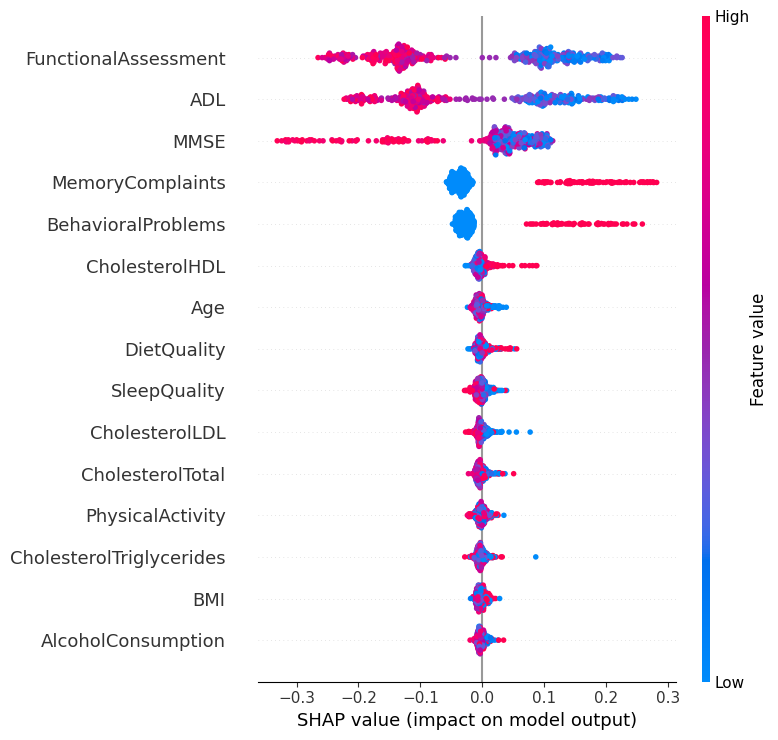

In [8]:
import shap

# 1. Ensure X only contains numeric features for the model
X = df.drop(columns=['PatientID', 'DoctorInCharge', 'Diagnosis'], errors='ignore')

# Convert any categorical/object columns to numeric/dummies if needed
X = pd.get_dummies(X, drop_first=True)
y = df['Diagnosis']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Compute SHAP Values using Explainer
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# 5. Plot Summary for Class 1 (Alzheimer's Diagnosis)
# If binary, shap_values[:, :, 1] isolates the positive diagnosis class
if len(shap_values.shape) == 3:
    shap.summary_plot(shap_values[:, :, 1], X_test, max_display=15)
else:
    shap.summary_plot(shap_values, X_test, max_display=15)

### Baseline Model Interpretability Results (Alzheimer's Dataset)
- **Model:** Random Forest Classifier evaluated using SHAP (SHapley Additive exPlanations) values.
- **Primary Features:** `FunctionalAssessment`, `ADL`, and `MMSE` demonstrate the highest impact on diagnostic classification.
- **Clinical Alignment:** Low MMSE scores combined with active memory/behavioral complaints show strong positive feature attribution toward dementia prediction, aligning with clinical consensus.

In [9]:
!pip install lifelines

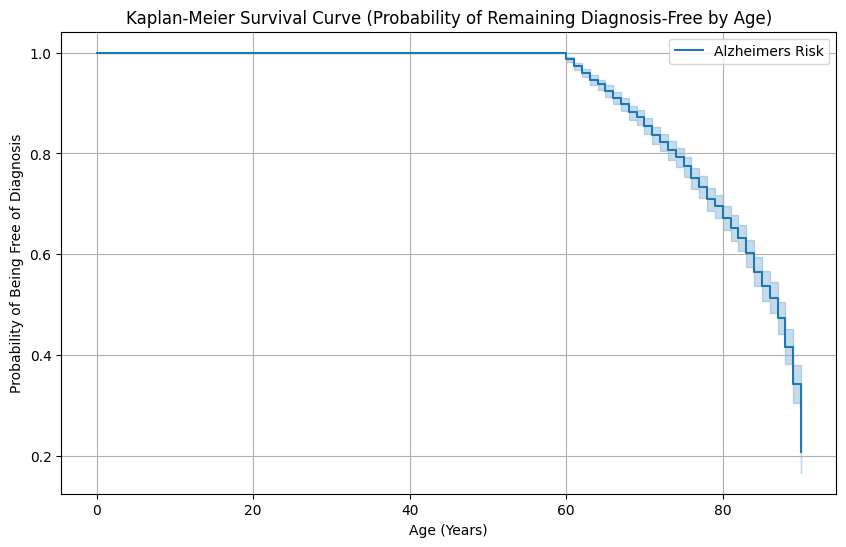

In [10]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# 1. Initialize Kaplan-Meier Fitter
kmf = KaplanMeierFitter()

# 2. Set 'Age' as duration (T) and 'Diagnosis' as event (E)
T = df['Age']
E = df['Diagnosis']

# 3. Fit data
kmf.fit(durations=T, event_observed=E, label='Alzheimers Risk')

# 4. Plot Survival Curve
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve (Probability of Remaining Diagnosis-Free by Age)')
plt.xlabel('Age (Years)')
plt.ylabel('Probability of Being Free of Diagnosis')
plt.grid(True)
plt.show()

<lifelines.CoxPHFitter: fitted with 2149 total observations, 1389 right-censored observations>
             duration col = 'Age'
                event col = 'Diagnosis'
      baseline estimation = breslow
   number of observations = 2149
number of events observed = 760
   partial log-likelihood = -5074.40
         time fit was run = 2026-07-24 04:01:42 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
MMSE               -0.04      0.96      0.00           -0.05           -0.03                0.95                0.97
AlcoholConsumption -0.00      1.00      0.01           -0.02            0.01                0.98                1.01
PhysicalActivity    0.00      1.00      0.01           -0.02            0.03                0.98                1.03
DietQuality         0.01      1.01      0.01           -0.01            0.04                0.99                1.04
BMI                 0.01      1.01      0.01           -0.00            0.02                1.00                1.02

                    cmp to     z      p  -log2(p)
covariate                                        
MMSE                  0.00 -8.70 <0.005     58.05
AlcoholConsumption    0.00 -0.49   0.62      0.69
PhysicalActivity      0.00  0.12   0.90      0.15
DietQuality           0.00  0.90   0.37      1.44
BMI                   0.00  1.43   0.15      2.71
---
Concordance = 0.60
Partial AIC = 10158.80
log-likelihood ratio test = 81.44 on 5 df
-log2(p) of ll-ratio test = 51.08

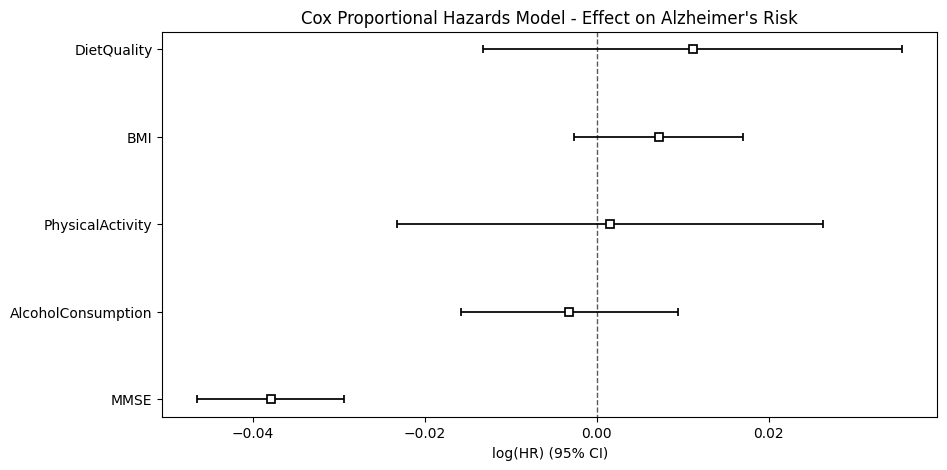

In [11]:
from lifelines import CoxPHFitter

# 1. Select a subset of relevant features for survival modeling
cols_to_use = ['Age', 'Diagnosis', 'MMSE', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'BMI']
df_cox = df[cols_to_use]

# 2. Fit Cox Proportional Hazards Model
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='Age', event_col='Diagnosis')

# 3. Print Summary Table (Hazard Ratios & p-values)
cph.print_summary()

# 4. Plot Feature Hazard Ratios
plt.figure(figsize=(10, 5))
cph.plot()
plt.title('Cox Proportional Hazards Model - Effect on Alzheimer\'s Risk')
plt.show()

In [12]:
pip install pandas numpy scikit-learn shap lifelines matplotlib

In [13]:
!pip install scikit-survival

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# 1. Prepare Features (X) and Structured Target (y)
# Filter numeric columns for simplicity
features = ['MMSE', 'FunctionalAssessment', 'ADL', 'MemoryComplaints',
            'BehavioralProblems', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'BMI']

X_surv = df[features]

# Create structured array required by sksurv: (Status, Time)
# Status: True if Diagnosed (Event=1), False if Censored (Event=0)
# Time: Age
y_surv = np.array(
    [(bool(event), age) for event, age in zip(df['Diagnosis'], df['Age'])],
    dtype=[('Status', '?'), ('Time', '<f8')]
)

# 2. Train/Test Split
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X_surv, y_surv, test_size=0.2, random_state=42)

# 3. Fit Random Survival Forest
rsf = RandomSurvivalForest(n_estimators=100, min_samples_split=10, min_samples_leaf=15, random_state=42)
rsf.fit(X_tr, y_tr)

# 4. Evaluate Concordance Index (C-Index)
c_index_train = rsf.score(X_tr, y_tr)
c_index_test = rsf.score(X_te, y_te)

print(f"RSF Train C-index: {c_index_train:.3f}")
print(f"RSF Test C-index:  {c_index_test:.3f}")

RSF Train C-index: 0.850
RSF Test C-index:  0.778


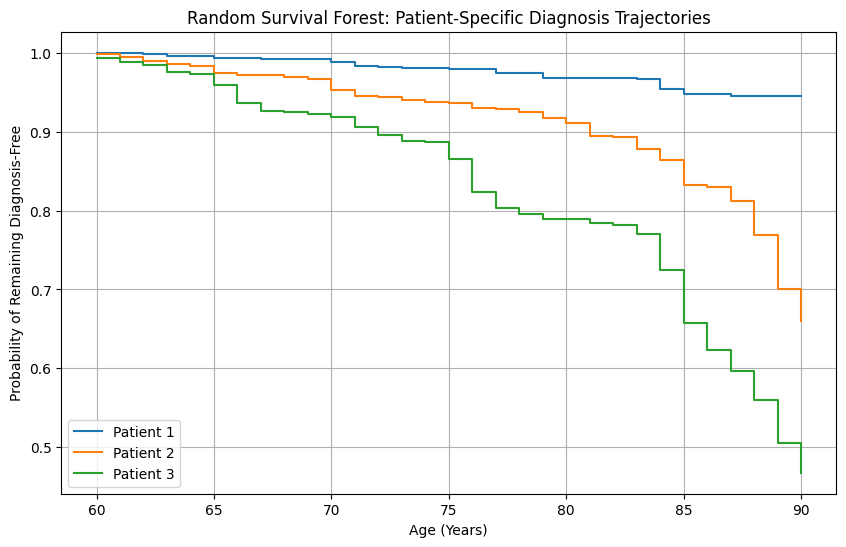

In [15]:
# Predict survival function for the first 3 test patients
surv_funcs = rsf.predict_survival_function(X_te.iloc[:3], return_array=False)

plt.figure(figsize=(10, 6))
for i, surv_func in enumerate(surv_funcs):
    plt.step(surv_func.x, surv_func.y, where="post", label=f"Patient {i+1}")

plt.ylabel("Probability of Remaining Diagnosis-Free")
plt.xlabel("Age (Years)")
plt.title("Random Survival Forest: Patient-Specific Diagnosis Trajectories")
plt.legend()
plt.grid(True)
plt.show()